In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

To visualise the molecules, you need RDKit. Install via 
>conda install -c conda-forge rdkit

In [2]:
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import Draw


You may also need to install an engine to read the xlsx file, 'openpyxl'
>conda install openpyxl

In [3]:
sol = pd.read_excel("Husskonen_Solubility_Features.xlsx", engine='openpyxl', verbose=False)
print(sol.shape)
print(sol.columns)


(932, 2261)
Index([                             0,          'Compound_Identifier',
                             'Source',                       'SMILES',
                            'LogS.M.',                           'MW',
                                'AMW',                           'Sv',
                                 'Se',                           'Sp',
       ...
                       'Psychotic-80',                 'Psychotic-50',
                       'Hypertens-80',                 'Hypertens-50',
                        'Hypnotic-80',                  'Hypnotic-50',
                      'Neoplastic-80',                'Neoplastic-50',
                       'Infective-80', 'Infective-50_x000D__x000D_\n'],
      dtype='object', length=2261)


Look at an example, the first data sample

In [4]:
for i in range(len(sol.iloc[0])):
    print(sol.columns[i], sol.iloc[0][sol.columns[i]])

0 1
Compound_Identifier HU_100
Source Huuskonen
SMILES c1ccc2ccc3nccnc3c2c1
LogS.M. -2.68
MW 180.22
AMW 8.192
Sv 15.623
Se 21.854
Sp 16.296
Si 24.242
Mv 0.71
Me 0.993
Mp 0.741
Mi 1.102
nAT 22
nSK 14
nBT 24
nBO 16
nBM 16
SCBO 24.0
RBN 0
RBF 0.0
nDB 0
nTB 0
nAB 16
nH 8
nC 12
nN 2
nO 0
nS 0
nF 0
nCL 0
nBR 0
nHM 0
nHet 2
nX 0
H% 36.4
C% 54.5
N% 9.1
O% 0.0
X% 0.0
nCsp3 0
nCsp2 12
nCsp 0
nCIC 3
nCIR 6
TRS 18
Rperim 14
Rbrid 2
MCD 1.0
RFD 0.286
RCI 1.286
NRS 1
NNRS 0.333
nR03 0
nR05 0
nR06 3
nR07 0
nR08 0
nR09 0
nR10 2
nR11 0
nR12 0
nBnz 2
ARR 1.0
D/Dtr03 0.0
D/Dtr05 0.0
D/Dtr06 62.233
D/Dtr07 0.0
D/Dtr08 0.0
D/Dtr09 0.0
D/Dtr10 69.159
D/Dtr11 0.0
D/Dtr12 0.0
ZM1 76
ZM1V 186
ZM1Kup 193.29
ZM1Mad 79.441
ZM1Per 280.68
ZM1MulPer 196.113
ZM2 91
ZM2V 211
ZM2Kup 215.93
ZM2Mad 94.886
ZM2Per 326.1
ZM2MulPer 222.319
ON0 6.333
ON0V 4.067
ON1 3.083
ON1V 1.31
Qindex 13
BBI 22
DBI 1.414
SNar 11.326
HNar 2.211
GNar 2.246
Xt 0.297
Dz 29.0
Ram 4
BLI 0.85
Pol 22
LPRS 50.995
MSD 3.317
SPI 0.0
PJI2 0.75
ECC 76


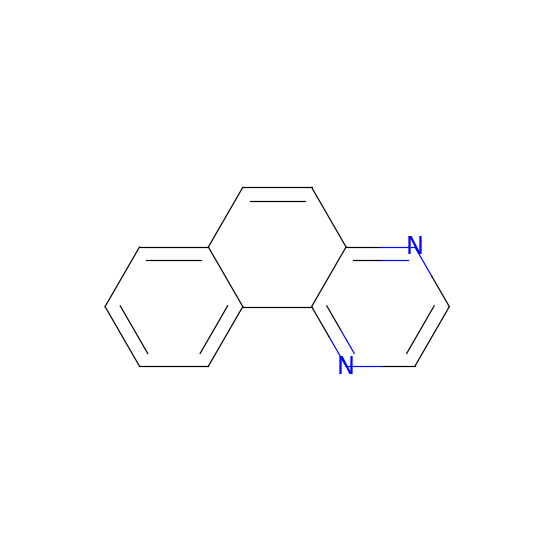

In [5]:
mol = Chem.MolFromSmiles(sol.iloc[0]['SMILES'])
fig = Draw.MolToMPL(mol)
plt.axis('off')
plt.show()

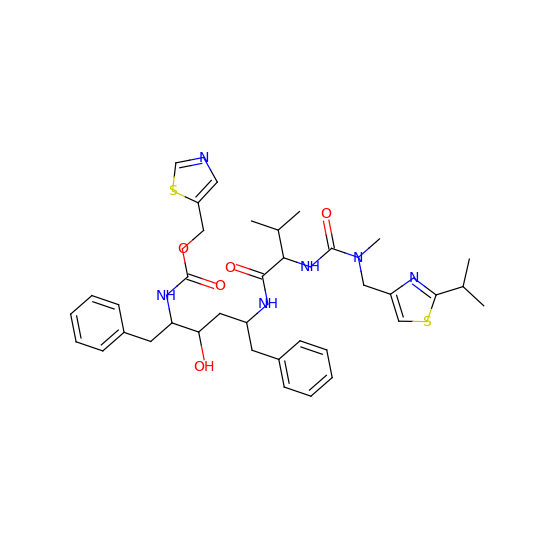

In [6]:
ritonavir = 'CC(C)C1=NC(=CS1)CN(C)C(=O)NC(C(C)C)C(=O)NC(CC2=CC=CC=C2)CC(C(CC3=CC=CC=C3)NC(=O)OCC4=CN=CS4)O'
ritonavir_mol = Chem.MolFromSmiles(ritonavir)
fig = Draw.MolToMPL(ritonavir_mol)
plt.axis('off')
plt.show()

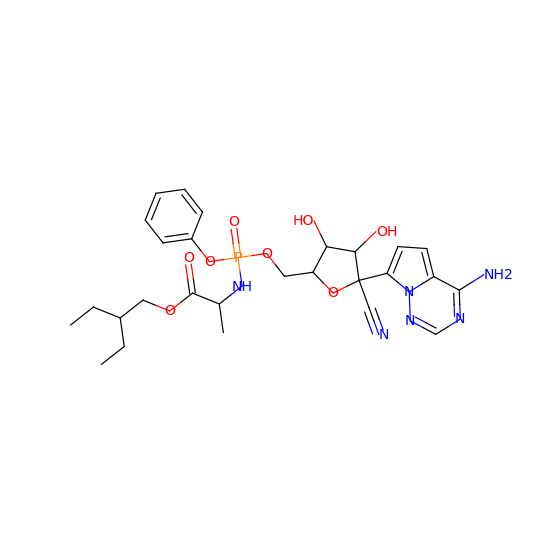

In [7]:
remdesivir = 'CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4'
remdesivir_mol = Chem.MolFromSmiles(remdesivir)
fig = Draw.MolToMPL(remdesivir_mol)
plt.axis('off')
plt.show()

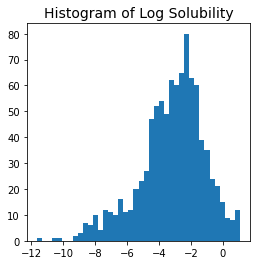

In [8]:
y = sol["LogS.M."].values
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(y, bins=40)
ax.set_title("Histogram of Log Solubility", fontsize=14);

Extract the data we are going to use to do the prediction

In [9]:
X = sol[sol.columns[5:-1]] # getting the relevant data
col_labels = sol.columns[5:-1]
X = X.to_numpy()
N, p = X.shape
print(X.shape)
print(y.shape)

(932, 2255)
(932,)


In [10]:
print(col_labels[:5])

Index(['MW', 'AMW', 'Sv', 'Se', 'Sp'], dtype='object')


Split data up in to train test split

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(652, 2255) (652,) (280, 2255) (280,)


## L2 Regularistion

Implement using matrix multiplication: 

$ \hat{w} = (X^T X + \gamma I) X^Ty$

$ \hat{y} = \hat{w} X$

In [110]:
gamma = 2.3
# get weights 
w = np.linalg.inv(X_train.T@X_train+gamma*np.identity(X_train.shape[1]))@(X_train.T@y_train)
# use it to estimate results
y_hat_train =  w@X_train.T
y_hat_test  = w@X_test.T

### Plot training and test predictions

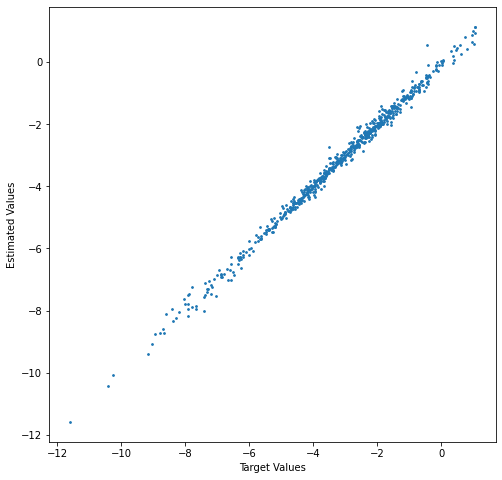

In [43]:
plt.figure(figsize=(8,8))
plt.scatter(y_train, y_hat_train, s=3);
plt.xlabel('Target Values')
plt.ylabel('Estimated Values');

Do the same for the test values. Identify those which don't fit the pattern. 

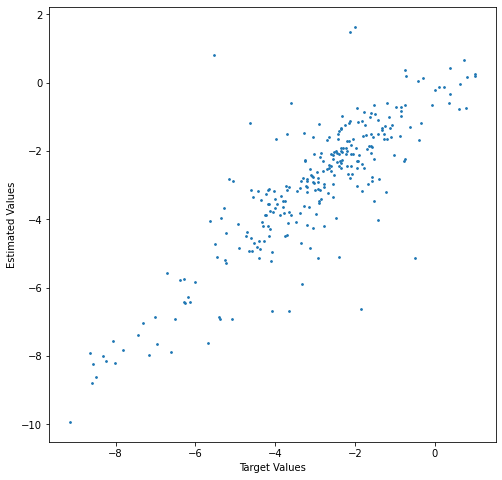

In [44]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_hat_test, s=3);
plt.xlabel('Target Values')
plt.ylabel('Estimated Values');

Can you see anything they have in common?

### Measure your success


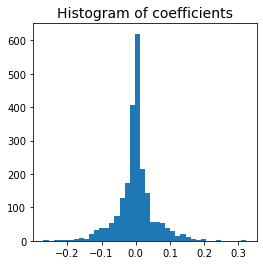

In [111]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(w, bins=40)
ax.set_title("Histogram of coefficients", fontsize=14);

## L1 Regularisation

Can't implement using matrix multiplication as solution is close form: 

$ \hat{w} = (X^T X)^{-1} * (\gamma I + X^Ty$)

$ \hat{y} = \hat{w} X$

### Gradient Decent

Therefore, try gradient decent as below:

$ E = |Xw-y||^2 + \gamma w $

$ \Delta E = X^T(Xw-y) + \gamma $

$ \hat{w}_{new} = \hat{w}_{old} - lr * (X^T(X\hat{w}_{old}-y)+ \gamma$)

In [94]:
gamma = 2.3
lr = 1e-11

# deffine error and error gradient
def error(x,w,y,gamma):
    return (x@w-y).T @ (x@w-y) + gamma*w

def error_grad(x,w,y,gamma):
    return x.T@(x@w-y)+gamma

# initialise weights
w2 = (np.random.rand(X_train.shape[1])-0.5)*0.1 #initialise between -0.05 and +0.05

# calc error and error gradient
err = error(X_train,w2,y_train,gamma)
err_grad = error_grad(X_train,w2,y_train,gamma)

# update weights
i = 0
while abs(sum(err)) > 100:
    i += 1
    err_grad = error_grad(X_train,w2,y_train,gamma) # calc error gradient
    w2 = w2 - lr*err_grad # update weights
    err = error(X_train,w2,y_train,gamma) # calc error
    if i%1000 == 0:
        #lr += 1e-13 # increases learning rate by 1 every 1000 iterations to speed up convergence
        print(sum(err))
    
# use it to estimate results
y_hat_train =  w2@X_train.T
y_hat_test  = w2@X_test.T

131973967.59142157
102141248.37944824
89498688.5825144
81616579.65761752
75501089.77713995
70294224.76660381
65704723.36154822
61603342.33423316
57913949.923696324
54581965.09059075
51564015.627933316
48823899.17147768
46330651.24711351
44057432.85075959
41980793.56248586
40080135.03109169
38337295.78744088
36736217.10255657
35312408.95430925
550070431739172.7
3.2329195766793226e+26
1.0058843344736456e+40
1.6503732658594214e+55
1.422351070490219e+72
6.414110135535003e+90
1.507615108975457e+111
1.8398967009919674e+133
1.1613808457340703e+157
3.777186416170937e+182
6.305418230231565e+209
5.382141932654886e+238
2.340135838326191e+269
5.163276683889097e+301


/var/folders/2z/0zp0f5_j6ss76lsdkg_2kzvc0000gn/T/ipykernel_27497/2408694914.py:20: RuntimeWarning: overflow encountered in double_scalars
  while abs(sum(err)) > 100:
/var/folders/2z/0zp0f5_j6ss76lsdkg_2kzvc0000gn/T/ipykernel_27497/2408694914.py:6: RuntimeWarning: overflow encountered in matmul
  return (x@w-y).T @ (x@w-y) + gamma*w


inf
inf
inf


KeyboardInterrupt: 

### Scikit-learn

In [114]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

In [119]:
clf = linear_model.Lasso(alpha = 0.3, max_iter = 50000)
clf.fit(X_train, y_train)
w2 = clf.coef_
y_pred_lasso = clf.fit(X_train, y_train).predict(X_test)
y_pred_lasso_train = clf.fit(X_train, y_train).predict(X_train)

### L1 vs L2 Comparison

#### Weights

Text(0.5, 1.0, 'Histogram of coefficients using L2')

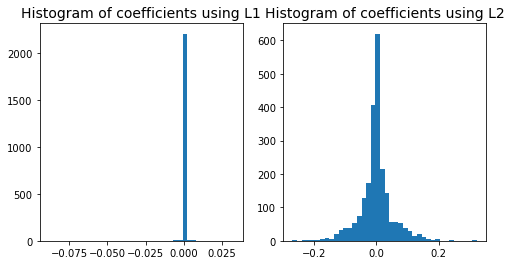

In [112]:
fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].hist(w2, bins=40)
ax[0].set_title("Histogram of coefficients using L1", fontsize=14)
ax[1].hist(w, bins=40)
ax[1].set_title("Histogram of coefficients using L2", fontsize=14)

#### Accuracy

In [117]:
# RMSE L1
MSE_1 = mean_squared_error(y_pred_lasso, y_test)
RMSE_1 = np.sqrt(MSE_1)
print('L1 RMSE: %.3f' %RMSE_1)

# RMSE L2
MSE_2 = mean_squared_error(y_hat_test, y_test)
RMSE_2 = np.sqrt(MSE_2)
print('L1 RMSE: %.3f' %RMSE_2)

L1 RMSE: 0.665
L1 RMSE: 1.088


## Finding the best parameters

Need to find the best parameters of the 2261 in the `sol` file which best represent solubility 